<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


**1.1. Загрузка и подготовка данных**

Обучающая выборка: (50000, 32, 32, 3)
Тестовая выборка: (10000, 32, 32, 3)


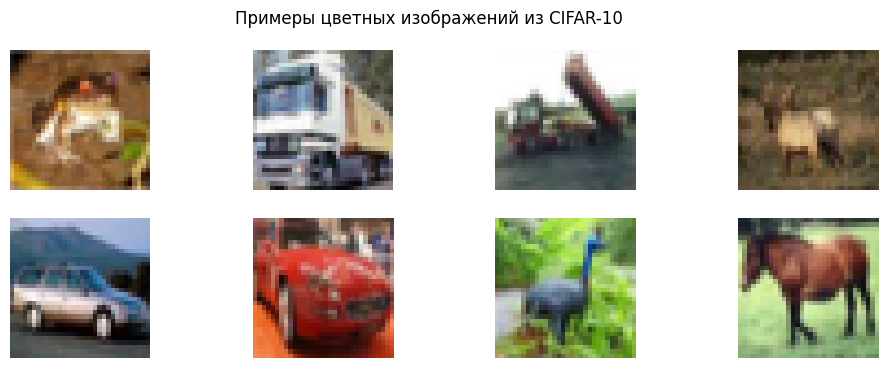

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
import tensorflow_datasets as tfds

# Загружаем CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Нормализуем значения пикселей [0, 255] -> [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Покажем несколько примеров
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.suptitle('Примеры цветных изображений из CIFAR-10')
plt.show()

**1.2. Преобразование RGB в оттенки серого**

Черно-белые изображения (вход): (50000, 32, 32, 1)
Цветные изображения (выход): (50000, 32, 32, 3)


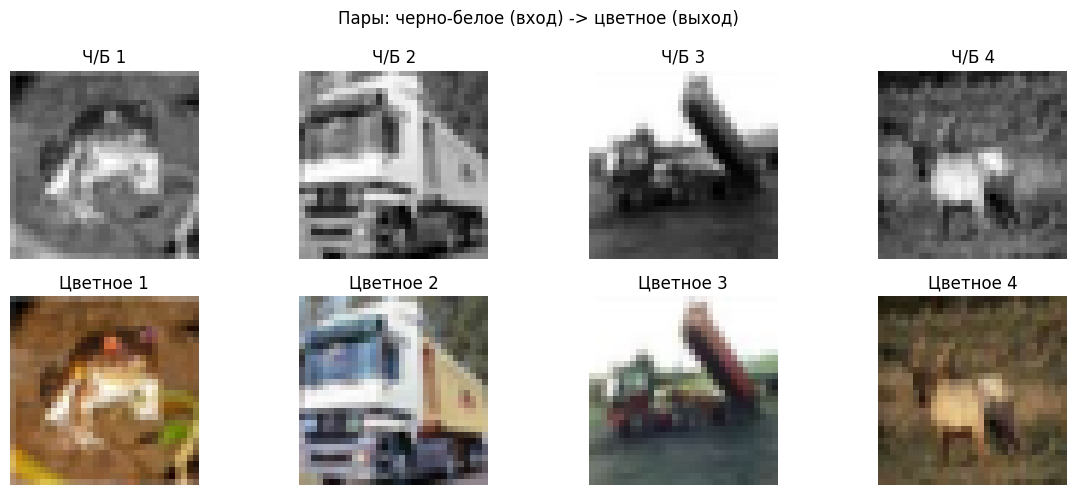

In [10]:
def rgb_to_grayscale(images):
    # Формула: Y = 0.299*R + 0.587*G + 0.114*B
    grayscale = 0.299 * images[:,:,:,0] + 0.587 * images[:,:,:,1] + 0.114 * images[:,:,:,2]
    # Добавляем размерность канала
    grayscale = np.expand_dims(grayscale, axis=-1)
    return grayscale

# Создаем черно-белые изображения (вход для автоэнкодера)
X_train_gray = rgb_to_grayscale(X_train)
X_test_gray = rgb_to_grayscale(X_test)

print(f"Черно-белые изображения (вход): {X_train_gray.shape}")
print(f"Цветные изображения (выход): {X_train.shape}")

# Визуализируем пары
plt.figure(figsize=(12, 5))
for i in range(4):
    # Черно-белое
    plt.subplot(2, 4, i+1)
    plt.imshow(X_train_gray[i].squeeze(), cmap='gray')
    plt.title(f'Ч/Б {i+1}')
    plt.axis('off')

    # Цветное
    plt.subplot(2, 4, i+5)
    plt.imshow(X_train[i])
    plt.title(f'Цветное {i+1}')
    plt.axis('off')
plt.suptitle('Пары: черно-белое (вход) -> цветное (выход)')
plt.tight_layout()
plt.show()

**1.3. Архитектура автоэнкодера**

In [11]:
def build_colorization_autoencoder(input_shape=(32, 32, 1)):
    # Энкодер
    encoder_input = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(encoder_input, decoder_output)
    return model

# Создаем модель
autoencoder = build_colorization_autoencoder()
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,379 (1.27 MB)

 Trainable params: 333,379 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**1.4. Компиляция и обучение**

In [12]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error для сравнения цветов
    metrics=['mae']
)

# Уменьшаем выборку для ускорения обучения (берем 10000 изображений)
X_train_small = X_train[:10000]
X_train_gray_small = X_train_gray[:10000]

# Обучение
history_color = autoencoder.fit(
    X_train_gray_small, X_train_small,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0283 - mae: 0.1293 - val_loss: 0.0182 - val_mae: 0.1022
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0167 - mae: 0.0972 - val_loss: 0.0165 - val_mae: 0.0971
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0152 - mae: 0.0920 - val_loss: 0.0145 - val_mae: 0.0896
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0144 - mae: 0.0894 - val_loss: 0.0141 - val_mae: 0.0886
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0137 - mae: 0.0868 - val_loss: 0.0134 - val_mae: 0.0852
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0134 - mae: 0.0855 - val_loss: 0.0136 - val_mae: 0.0872
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0129 - mae: 0.0838 - val_loss: 0.0130 - val_mae: 0.0858
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0125 - mae: 0.0824 - val_loss: 0.0129 - val_mae: 0.0851
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - l

**1.5. Визуализация результатов обучения**

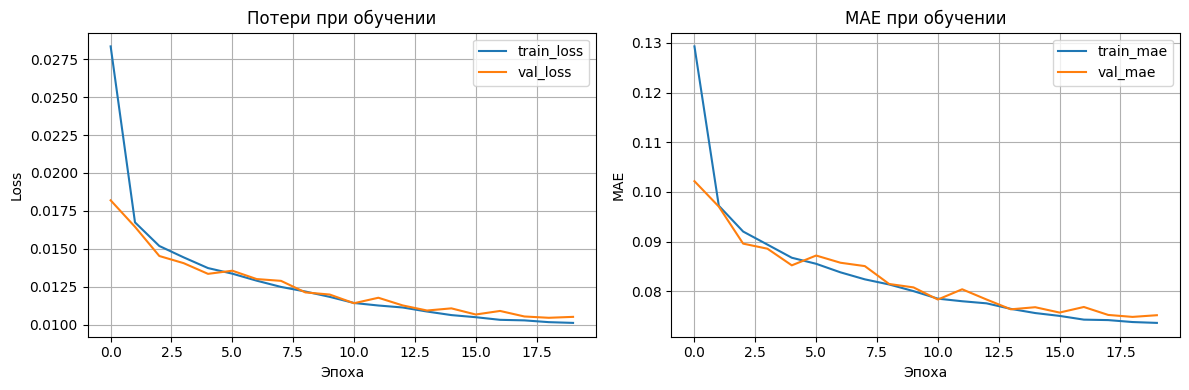

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_color.history['loss'], label='train_loss')
plt.plot(history_color.history['val_loss'], label='val_loss')
plt.title('Потери при обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_color.history['mae'], label='train_mae')
plt.plot(history_color.history['val_mae'], label='val_mae')
plt.title('MAE при обучении')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**1.6. Тестирование модели на новых изображениях**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


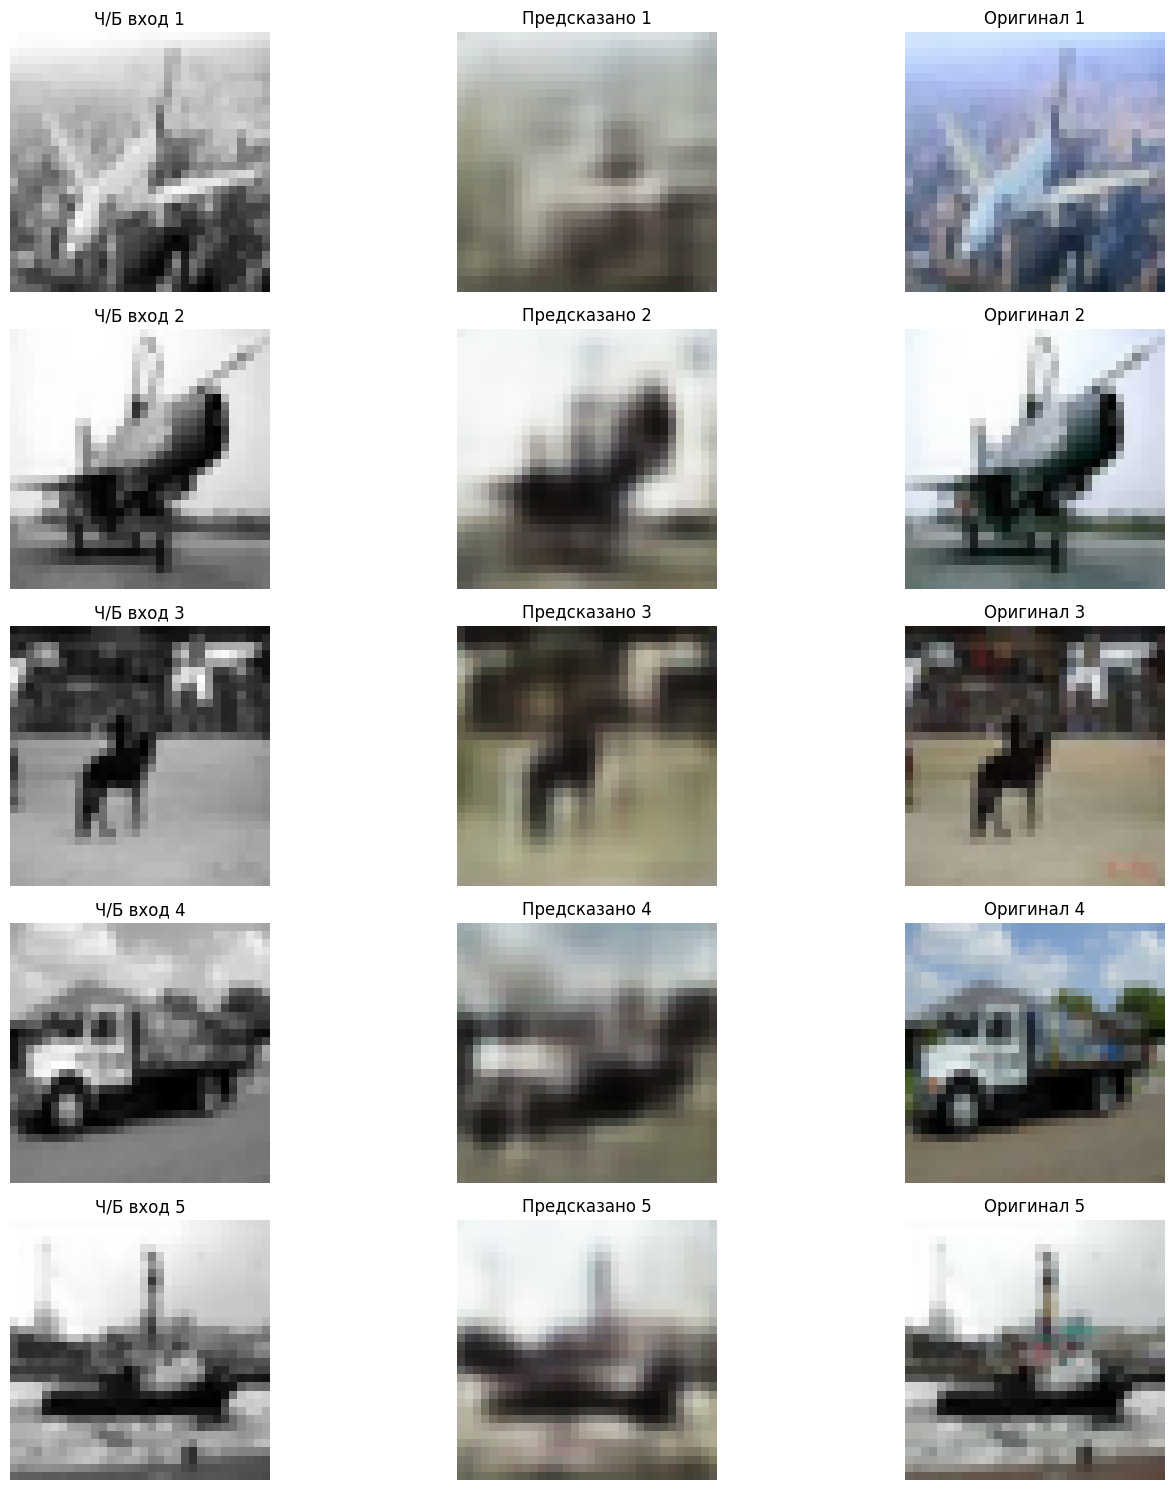

In [15]:
# Берем несколько изображений из тестовой выборки
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказываем цвета
X_test_gray_sample = X_test_gray[test_indices]
pred_colors = autoencoder.predict(X_test_gray_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Черно-белое (вход)
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_gray[idx].squeeze(), cmap='gray')
    plt.title(f'Ч/Б вход {i+1}')
    plt.axis('off')

    # Предсказанное цветное
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(pred_colors[i])
    plt.title(f'Предсказано {i+1}')
    plt.axis('off')

    # Оригинальное цветное
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

**2.1. Загрузка датасета**

In [16]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Нормализация
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Обучающая: {X_train.shape}")
print(f"Тестовая: {X_test.shape}")

Обучающая: (50000, 32, 32, 3)
Тестовая: (10000, 32, 32, 3)


**2.2. Добавление шума к изображениям**

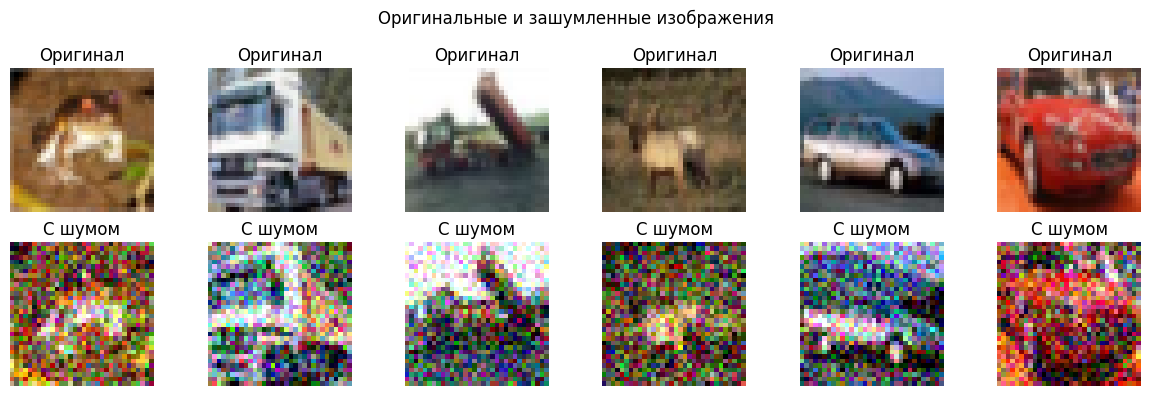

In [17]:
def add_gaussian_noise(images, noise_factor=0.2):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

# Создаем зашумленные версии
X_train_noisy = add_gaussian_noise(X_train)
X_test_noisy = add_gaussian_noise(X_test)

# Визуализируем
plt.figure(figsize=(12, 4))
for i in range(6):
    # Оригинал
    plt.subplot(2, 6, i+1)
    plt.imshow(X_train[i])
    plt.title('Оригинал')
    plt.axis('off')

    # Зашумленный
    plt.subplot(2, 6, i+7)
    plt.imshow(X_train_noisy[i])
    plt.title('С шумом')
    plt.axis('off')
plt.suptitle('Оригинальные и зашумленные изображения')
plt.tight_layout()
plt.show()

**2.3. Создание архитектуры автоэнкодера для удаления шума**

In [18]:
def build_denoising_autoencoder(input_shape=(32, 32, 3)):
    # Энкодер
    input_img = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Декодер
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    return model

denoiser = build_denoising_autoencoder()
denoiser.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**2.4. Компиляция и обучение**

In [19]:
denoiser.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Берем часть данных для ускорения
X_train_small = X_train[:10000]
X_train_noisy_small = X_train_noisy[:10000]

# Обучение
history_denoise = denoiser.fit(
    X_train_noisy_small, X_train_small,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0188 - mae: 0.1012 - val_loss: 0.0098 - val_mae: 0.0744
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0089 - mae: 0.0702 - val_loss: 0.0085 - val_mae: 0.0687
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0077 - mae: 0.0654 - val_loss: 0.0071 - val_mae: 0.0626
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0071 - mae: 0.0629 - val_loss: 0.0068 - val_mae: 0.0609
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0067 - mae: 0.0610 - val_loss: 0.0069 - val_mae: 0.0619
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0064 - mae: 0.0594 - val_loss: 0.0068 - val_mae: 0.0618
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0063 - mae: 0.0589 - val_loss: 0.0061 - val_mae: 0.0578
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0060 - mae: 0.0575 - val_loss: 0.0059 - val_mae: 0.0565
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/

**2.5. Визуализация результатов**

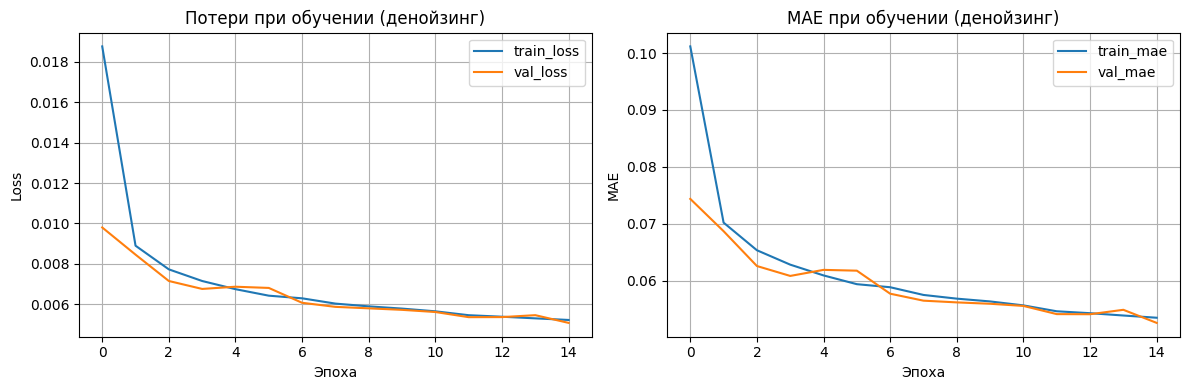

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step


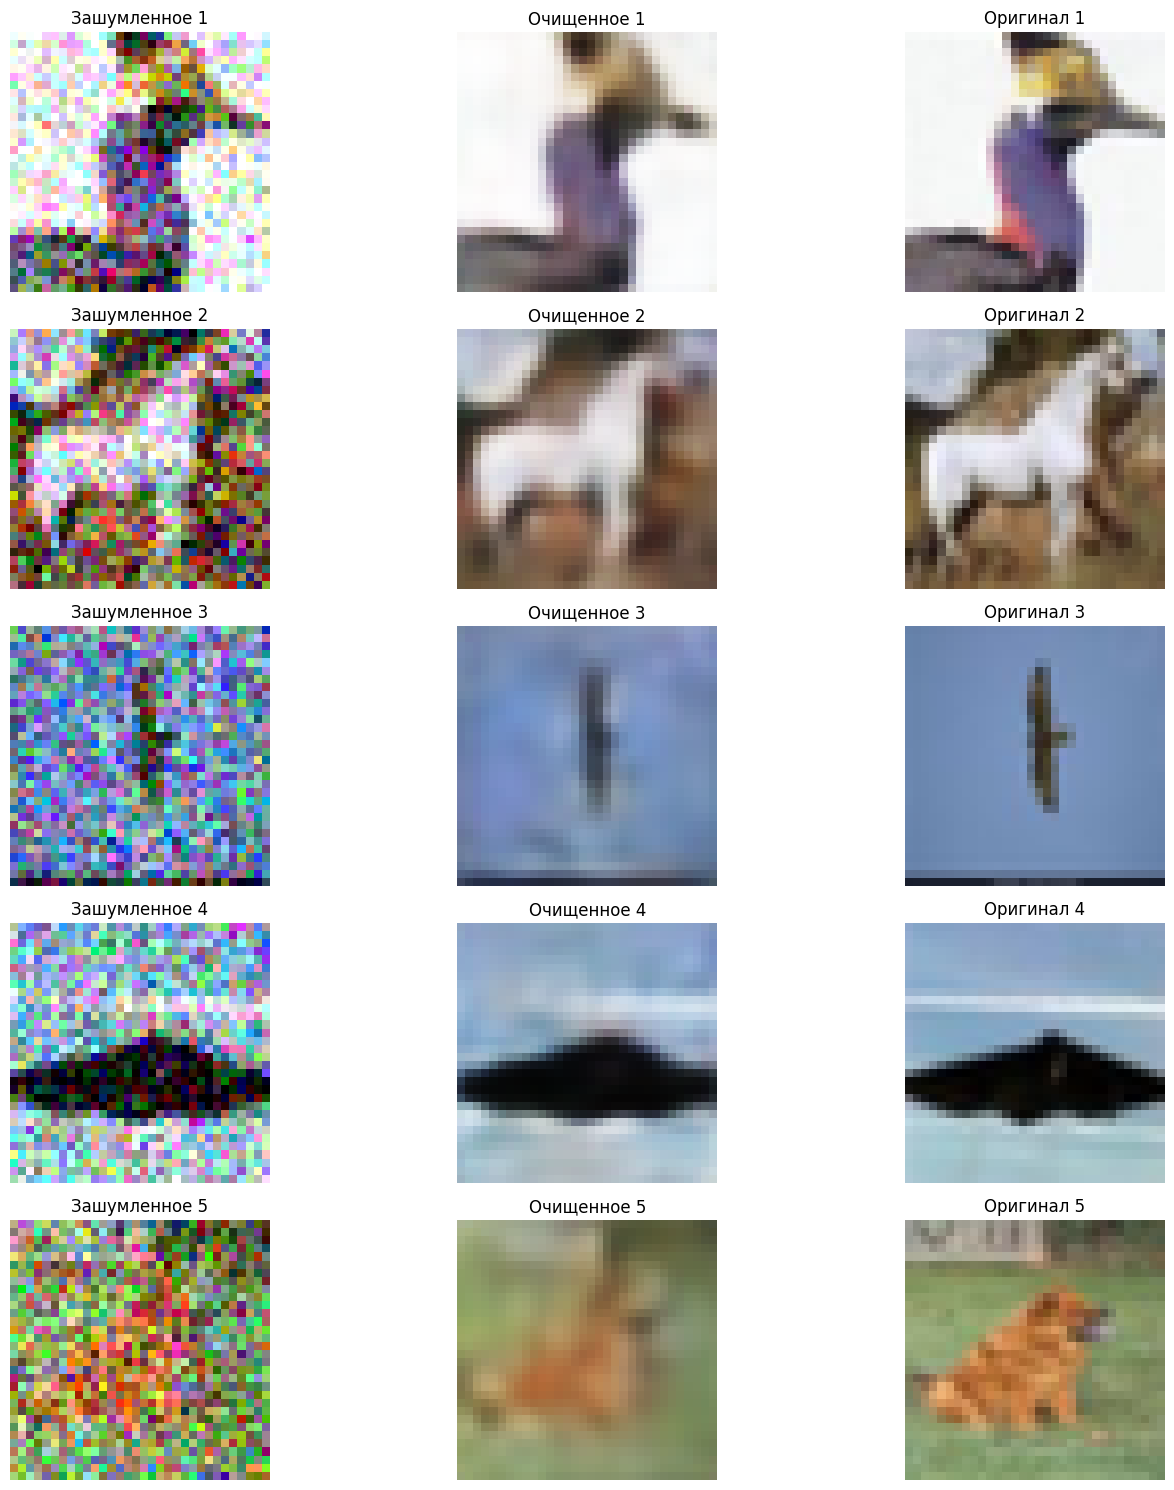

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_denoise.history['loss'], label='train_loss')
plt.plot(history_denoise.history['val_loss'], label='val_loss')
plt.title('Потери при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_denoise.history['mae'], label='train_mae')
plt.plot(history_denoise.history['val_mae'], label='val_mae')
plt.title('MAE при обучении (денойзинг)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Тестирование
n_samples = 5
test_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Предсказания
X_test_noisy_sample = X_test_noisy[test_indices]
denoised = denoiser.predict(X_test_noisy_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Зашумленное
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_noisy[idx])
    plt.title(f'Зашумленное {i+1}')
    plt.axis('off')

    # Очищенное (предсказание)
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(denoised[i])
    plt.title(f'Очищенное {i+1}')
    plt.axis('off')

    # Оригинал
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test[idx])
    plt.title(f'Оригинал {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

**3.1. Подготовка данных**

In [21]:
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img
from skimage.transform import resize

# Берем изображения из CIFAR-10
X_train = X_train[:5000]  # Берем 5000 для обучения
X_test = X_test[:1000]    # 1000 для теста

# Создаем пары: маленькие (64x64) -> большие (128x128)
# Но в CIFAR-10 исходный размер 32x32, поэтому сначала увеличим до 128x128

def create_low_high_pairs(images, low_size=(64, 64), high_size=(128, 128)):
    low_images = []
    high_images = []

    for img in images:
        # Высокое разрешение (128x128)
        high = resize(img, high_size, preserve_range=True)
        # Низкое разрешение (64x64) - сначала уменьшаем, потом увеличиваем
        low = resize(img, low_size, preserve_range=True)
        low = resize(low, high_size, preserve_range=True)

        high_images.append(high)
        low_images.append(low)

    return np.array(low_images), np.array(high_images)

# Создаем пары
X_low, X_high = create_low_high_pairs(X_train)
X_test_low, X_test_high = create_low_high_pairs(X_test)

print(f"Низкое разрешение (вход): {X_low.shape}")
print(f"Высокое разрешение (выход): {X_high.shape}")

Низкое разрешение (вход): (5000, 128, 128, 3)
Высокое разрешение (выход): (5000, 128, 128, 3)


**3.2. Визуализация пар**


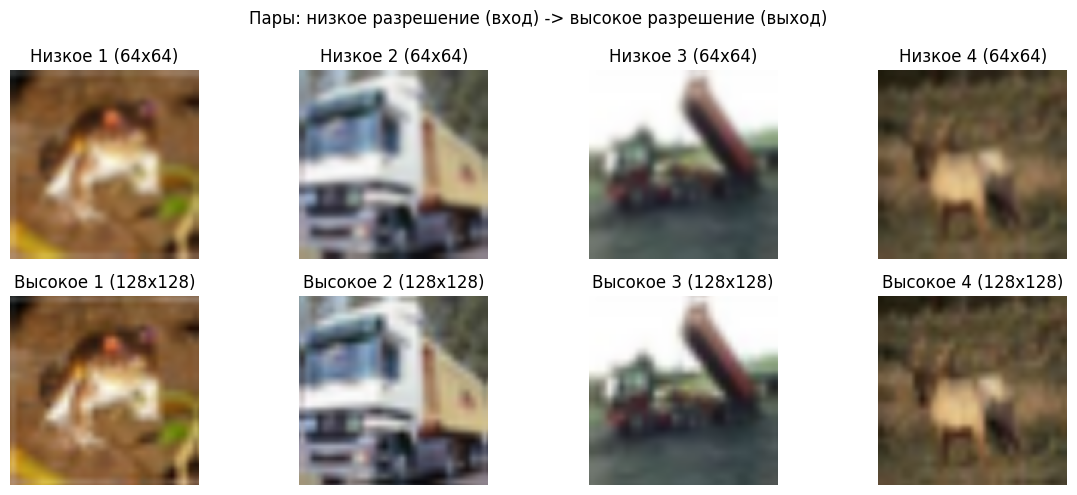

In [22]:
plt.figure(figsize=(12, 5))
for i in range(4):
    # Низкое разрешение
    plt.subplot(2, 4, i+1)
    plt.imshow(X_low[i])
    plt.title(f'Низкое {i+1} (64x64)')
    plt.axis('off')

    # Высокое разрешение
    plt.subplot(2, 4, i+5)
    plt.imshow(X_high[i])
    plt.title(f'Высокое {i+1} (128x128)')
    plt.axis('off')
plt.suptitle('Пары: низкое разрешение (вход) -> высокое разрешение (выход)')
plt.tight_layout()
plt.show()

**3.3. Создание архитектуры для апскейлинга**

In [23]:
def build_upscale_autoencoder(input_shape=(128, 128, 3)):
    input_img = layers.Input(shape=input_shape)

    # Энкодер
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)

    # Декодер (увеличиваем разрешение)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    return model

upscaler = build_upscale_autoencoder()
upscaler.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

**3.4. Компиляция**

In [24]:
upscaler.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Обучение (уменьшаем количество данных для скорости)
X_low_small = X_low[:2000]
X_high_small = X_high[:2000]

history_upscale = upscaler.fit(
    X_low_small, X_high_small,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 578ms/step - loss: 0.0248 - mae: 0.1146 - val_loss: 0.0034 - val_mae: 0.0424
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - loss: 0.0028 - mae: 0.0385 - val_loss: 0.0019 - val_mae: 0.0318
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - loss: 0.0016 - mae: 0.0300 - val_loss: 0.0010 - val_mae: 0.0246
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - loss: 7.8898e-04 - mae: 0.0207 - val_loss: 5.4524e-04 - val_mae: 0.0169
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - loss: 4.8869e-04 - mae: 0.0164 - val_loss: 4.7953e-04 - val_mae: 0.0165
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - loss: 3.6936e-04 - mae: 0.0143 - val_loss: 3.3820e-04 - val_mae: 0.0133
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 156ms/step - loss: 4.7400e-04 - mae: 0.0164 - val_loss: 4.1875e-04 - val_mae: 0.0157
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - loss: 2.8489e-04 - mae: 0.0125 - val_loss: 2.8432e-04 - val_mae: 0.0131
Epoch 9/15
50/

**3.5. Визуализация результатов**

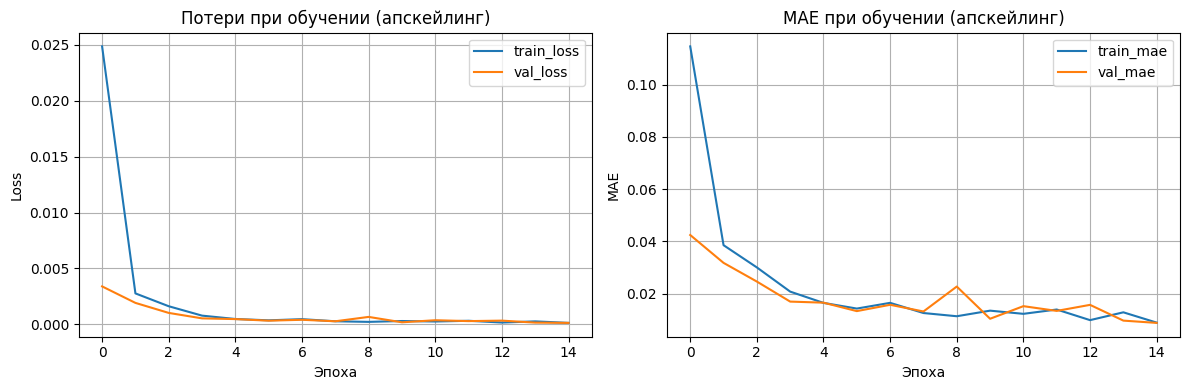

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


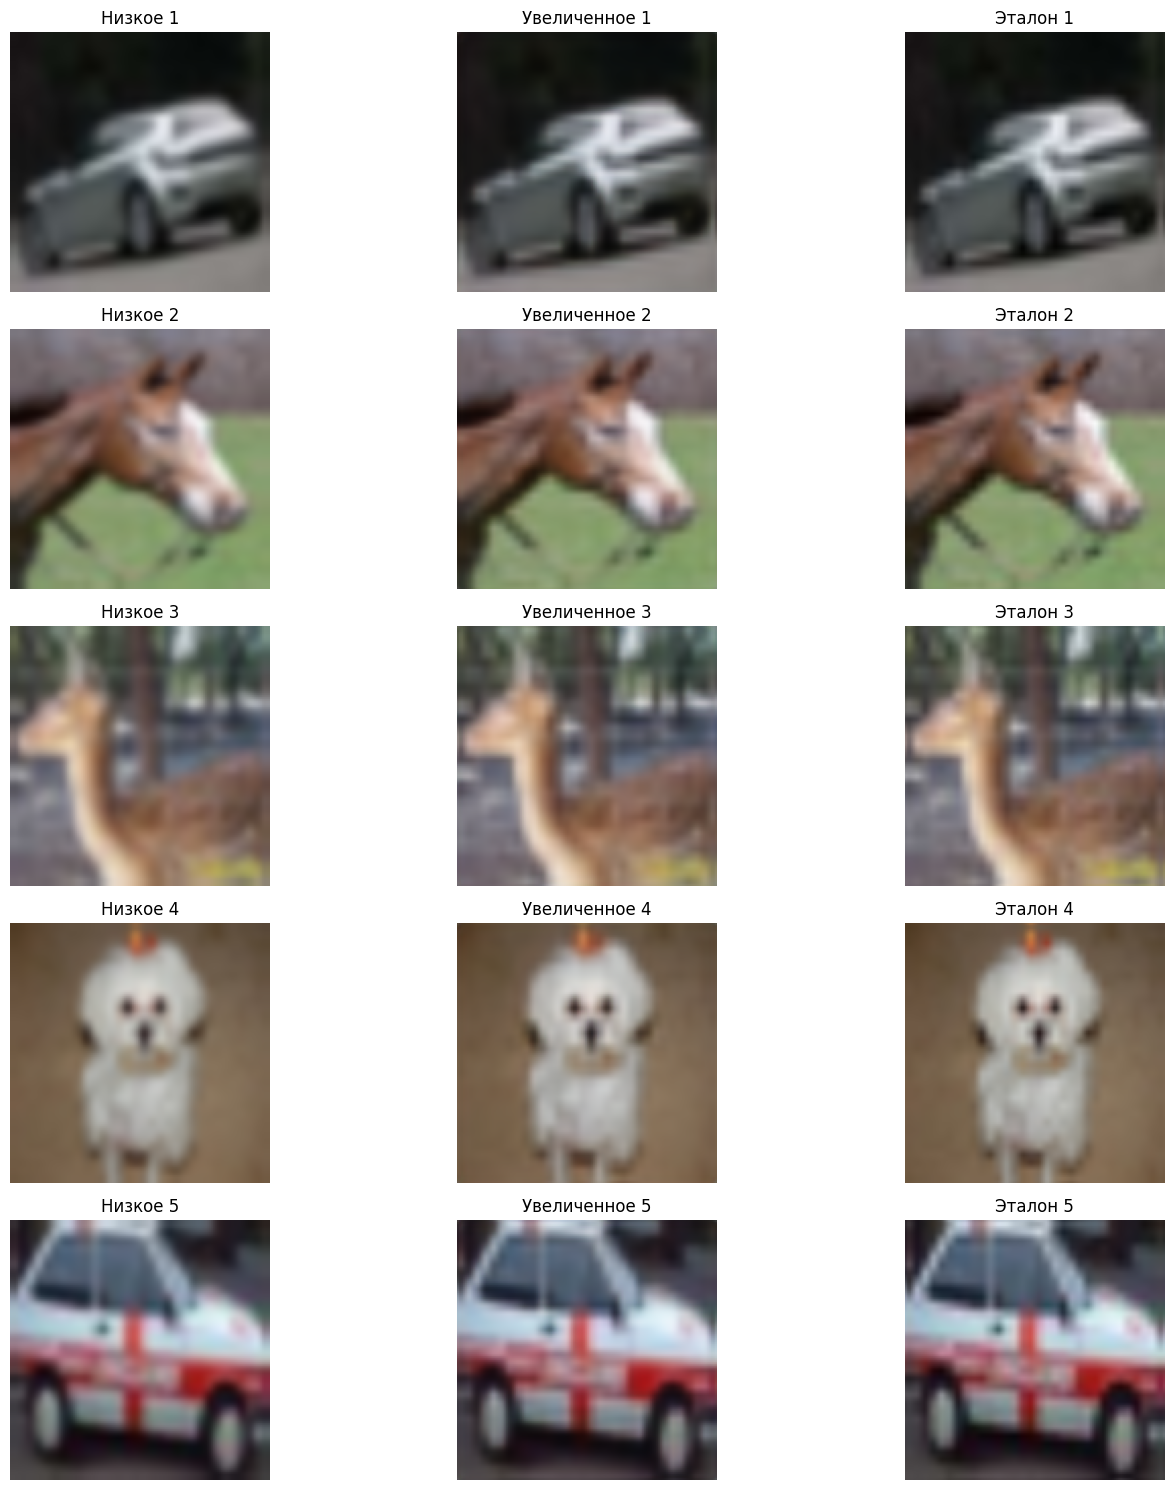

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_upscale.history['loss'], label='train_loss')
plt.plot(history_upscale.history['val_loss'], label='val_loss')
plt.title('Потери при обучении (апскейлинг)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_upscale.history['mae'], label='train_mae')
plt.plot(history_upscale.history['val_mae'], label='val_mae')
plt.title('MAE при обучении (апскейлинг)')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Тестирование
n_samples = 5
test_indices = np.random.choice(len(X_test_low), n_samples, replace=False)

# Предсказания
X_test_low_sample = X_test_low[test_indices]
upscaled = upscaler.predict(X_test_low_sample)

# Визуализация
plt.figure(figsize=(15, n_samples * 3))
for i, idx in enumerate(test_indices):
    # Низкое разрешение
    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(X_test_low[idx])
    plt.title(f'Низкое {i+1}')
    plt.axis('off')

    # Увеличенное (предсказание)
    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(upscaled[i])
    plt.title(f'Увеличенное {i+1}')
    plt.axis('off')

    # Эталон высокое
    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(X_test_high[idx])
    plt.title(f'Эталон {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**3.6. Адаптация для произвольных размеров**

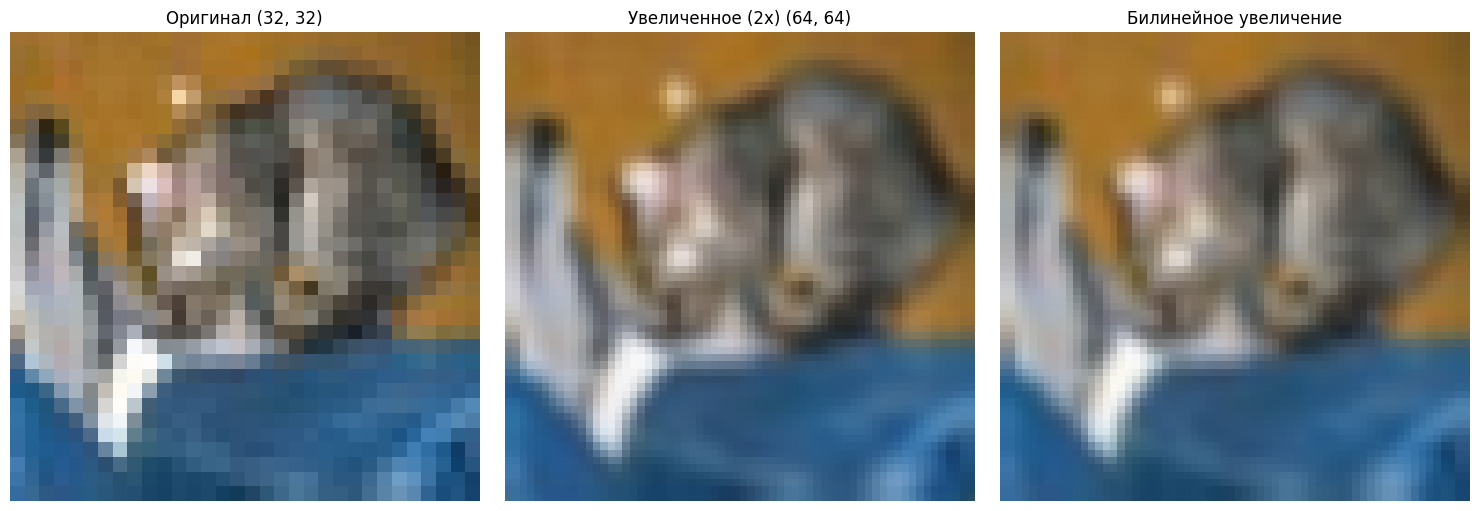

In [30]:
def upscale_any_size(image, model, target_scale=2):
    """
    Увеличивает изображение в target_scale раз
    image: входное изображение (любого размера)
    model: обученная модель
    target_scale: коэффициент увеличения (по умолчанию 2)
    """
    from skimage.transform import resize

    # Получаем размеры
    h, w = image.shape[:2]
    new_h, new_w = h * target_scale, w * target_scale

    # Сначала уменьшаем до размера, который ожидает модель (128x128)
    temp = resize(image, (128, 128), preserve_range=True)

    # Предсказываем
    pred = model.predict(np.expand_dims(temp, axis=0), verbose=0)
    result = pred[0]

    # Масштабируем до нужного размера
    result = resize(result, (new_h, new_w), preserve_range=True)

    return result

# Тестируем на произвольном изображении
from skimage import data

# Берем изображение из CIFAR-10
test_img = X_test[0]

# Увеличиваем в 2 раза
upscaled_2x = upscale_any_size(test_img, upscaler, target_scale=2)

# Визуализация
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title(f'Оригинал {test_img.shape[:2]}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(upscaled_2x)
plt.title(f'Увеличенное (2x) {upscaled_2x.shape[:2]}')
plt.axis('off')

plt.subplot(1, 3, 3)
# Билинейное увеличение - этов ообще чё?
from skimage.transform import resize
simple_upscale = resize(test_img, (test_img.shape[0]*2, test_img.shape[1]*2), preserve_range=True)
plt.imshow(simple_upscale)
plt.title(f'Билинейное увеличение')
plt.axis('off')

plt.tight_layout()
plt.show()